# Lab 11 – Exploratory Data Analysis pe setul EDA3


## 1. Importuri si configurare



In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [ ]:

url = "https://www.stat.cmu.edu/~hseltman/309/Book/data/EDA3.dat"

df = pd.read_csv(url, sep=r"\s+")

df["Age"] = pd.to_numeric(df["Age"])
df["Strength"] = pd.to_numeric(df["Strength"])

df.head()
df.to_csv("eda3.csv", index=False)

print("Fisierul eda3.csv a fost salvat.")

Fisierul eda3.csv a fost salvat.


## 2. Incarcarea setului de date EDA3


In [ ]:
DATA_PATH = "eda3.csv"
possible_paths = [
    DATA_PATH,
    "data/eda3.csv",
    "./data/eda3.csv",
    "../data/eda3.csv",
]

existing_paths = [p for p in possible_paths if os.path.exists(p)]
if not existing_paths:
    raise FileNotFoundError(
        "Nu am gasit fisierul EDA3. "
    )

DATA_PATH = existing_paths[0]
df = pd.read_csv(DATA_PATH)

print(f"Fisier incarcat: {DATA_PATH}")
df.head()


Fisier incarcat: eda3.csv


,ID,Age,AgeGroup,Strength,Sex,Party
0,1,27,"(21,42]",26,F,Rep
1,2,58,"(42,62]",22,F,Rep
2,3,32,"(21,42]",29,F,Dem
3,4,51,"(42,62]",18,F,Dem
4,5,38,"(21,42]",28,F,Rep


## 3. Overview general al datelor

Aici verificam dimensiunea setului de date, tipurile de coloane, primele observatii și numarul de valori lipsa.


In [ ]:
print("Dimensiune dataset, format (randuri, coloane):", df.shape)
display(df.head())

print("\nInformatii despre coloane si tipuri de date:")
df.info()


Dimensiune dataset, format (randuri, coloane): (60, 6)


,ID,Age,AgeGroup,Strength,Sex,Party
0,1,27,"(21,42]",26,F,Rep
1,2,58,"(42,62]",22,F,Rep
2,3,32,"(21,42]",29,F,Dem
3,4,51,"(42,62]",18,F,Dem
4,5,38,"(21,42]",28,F,Rep



Informatii despre coloane si tipuri de date:
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ID        60 non-null     int64
 1   Age       60 non-null     int64
 2   AgeGroup  60 non-null     str  
 3   Strength  60 non-null     int64
 4   Sex       60 non-null     str  
 5   Party     60 non-null     str  
dtypes: int64(3), str(3)
memory usage: 3.6 KB


In [ ]:
missing_summary = (
    df.isna().sum()
      .to_frame("valori_lipsa")
      .assign(procent_lipsă=lambda x: 100 * x["valori_lipsa"] / len(df))
      .sort_values("procent_lipsă", ascending=False)
)

missing_summary


,valori_lipsa,procent_lipsă
ID,0,0.0
Age,0,0.0
AgeGroup,0,0.0
Strength,0,0.0
Sex,0,0.0
Party,0,0.0


## 4. Separarea variabilelor numerice și categoriale



In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "ID"]
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Coloane numerice:", numeric_cols)
print("\nColoane categoriale:", categorical_cols)


Coloane numerice: ['Age', 'Strength']

Coloane categoriale: ['AgeGroup', 'Sex', 'Party']


## 5. Statistici descriptive generale



In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,60.0,30.500000,17.464249,1.0,15.75,30.5,45.25,60.0
Age,60.0,53.000000,17.458911,22.0,37.50,55.5,66.00,82.0
Strength,60.0,19.583333,5.636719,9.0,16.00,20.0,23.00,35.0


In [ ]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame("frecventa"))



--- AgeGroup ---


,frecventa
AgeGroup,
"(62,82]",24
"(21,42]",20
"(42,62]",16



--- Sex ---


,frecventa
Sex,
F,36
M,24



--- Party ---


,frecventa
Party,
Rep,34
Dem,26


## 6. Alegerea unei variabile numerice pentru analiza univariata



In [ ]:
USER_NUMERIC_VAR = "Strength"

if USER_NUMERIC_VAR is None:
    if not numeric_cols:
        raise ValueError("Datasetul nu contine coloane numerice.")
    var = numeric_cols[0]
else:
    var = USER_NUMERIC_VAR

print("Variabila analizata:", var)
series = df[var].dropna()
series.head()


Variabila analizata: Strength


0    26
1    22
2    29
3    18
4    28
Name: Strength, dtype: int64

## 7. Analiză univariata



In [ ]:
univariate_stats = pd.DataFrame({
    "indicator": [
        "count", "mean", "median", "mode", "min", "Q1", "Q3", "max",
        "variance", "standard_deviation", "IQR", "skewness", "kurtosis"
    ],
    "valoare": [
        series.count(),
        series.mean(),
        series.median(),
        series.mode().iloc[0] if not series.mode().empty else np.nan,
        series.min(),
        series.quantile(0.25),
        series.quantile(0.75),
        series.max(),
        series.var(ddof=1),
        series.std(ddof=1),
        series.quantile(0.75) - series.quantile(0.25),
        stats.skew(series),
        stats.kurtosis(series, fisher=True),
    ]
})

univariate_stats


,indicator,valoare
0,count,60.000000
1,mean,19.583333
2,median,20.000000
3,mode,16.000000
4,min,9.000000
5,Q1,16.000000
6,Q3,23.000000
7,max,35.000000
8,variance,31.772599
9,standard_deviation,5.636719


Interpretare automata: folosim skewness pentru a observa asimetria si kurtosis pentru a observa cat de grele sunt cozile distributiei comparativ cu o distributie normala.

> Add blockquote




In [ ]:
skew_value = stats.skew(series)
kurt_value = stats.kurtosis(series, fisher=True)

if skew_value > 0.5:
    skew_text = "distributia este asimetrica pozitiv, cu coada spre dreapta"
elif skew_value < -0.5:
    skew_text = "distributia este asimetrica negativ, cu coada spre stanga"
else:
    skew_text = "distributia este aproximativ simetrica"

if kurt_value > 0:
    kurt_text = "kurtosis pozitiv: distributia are cozi mai grele decat distributia normala"
elif kurt_value < 0:
    kurt_text = "kurtosis negativ: distributia este mai plata"
else:
    kurt_text = "kurtosis apropiat de zero: forma este apropiată de cea normala"

print(f"Skewness = {skew_value:.3f}: {skew_text}.")
print(f"Kurtosis = {kurt_value:.3f}: {kurt_text}.")


Skewness = 0.183: distributia este aproximativ simetrica.
Kurtosis = -0.266: kurtosis negativ: distributia este mai plata.


Analiza variabilei: Age
Mean: 53.00
Median: 55.50
Standard deviation: 17.46
Skewness: -0.1192
Kurtosis: -1.2552


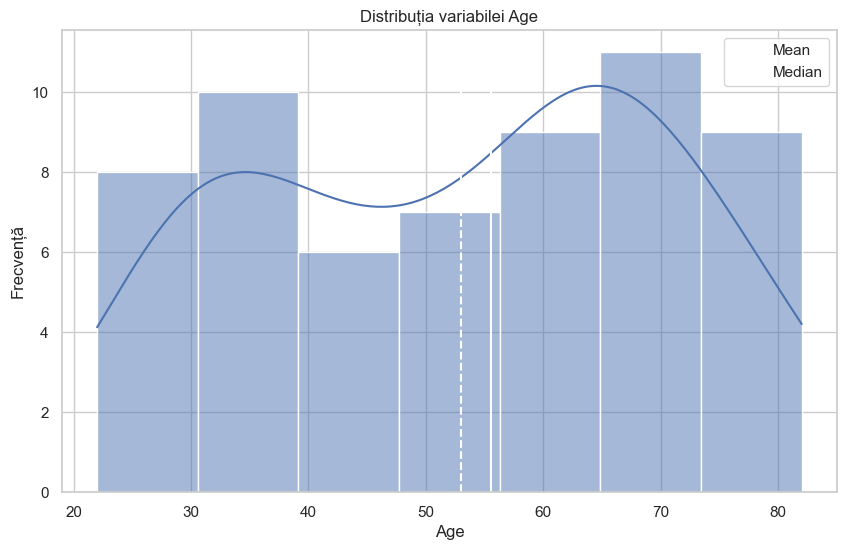

Distributia este aproximativ simetrica.
Distributia este mai plata decat distributia normala.


Analiza variabilei: Strength
Mean: 19.58
Median: 20.00
Standard deviation: 5.64
Skewness: 0.1827
Kurtosis: -0.2663


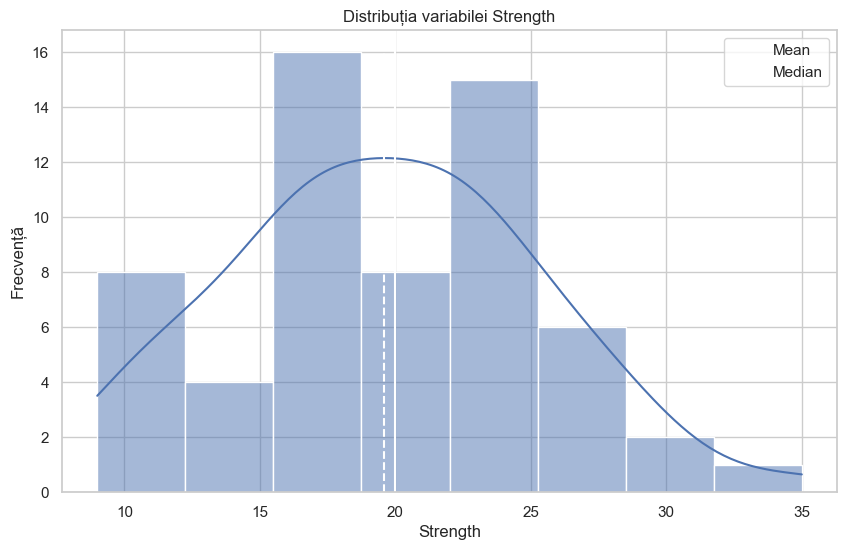

Distributia este aproximativ simetrica.
Distributia este mai plata decat distributia normala.




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

numeric_analysis_cols = ["Age", "Strength"]

for col in numeric_analysis_cols:

    series = df[col].dropna()

    skewness_value = stats.skew(series)
    kurtosis_value = stats.kurtosis(series, fisher=True)

    print("=" * 60)
    print(f"Analiza variabilei: {col}")
    print("=" * 60)

    print(f"Mean: {series.mean():.2f}")
    print(f"Median: {series.median():.2f}")
    print(f"Standard deviation: {series.std():.2f}")
    print(f"Skewness: {skewness_value:.4f}")
    print(f"Kurtosis: {kurtosis_value:.4f}")

    plt.figure(figsize=(10,6))

    sns.histplot(series, kde=True)

    plt.axvline(series.mean(), linestyle="--", label="Mean")
    plt.axvline(series.median(), linestyle="-", label="Median")

    plt.title(f"Distribuția variabilei {col}")
    plt.xlabel(col)
    plt.ylabel("Frecvență")

    plt.legend()

    plt.show()

    if skewness_value > 0.5:
        print("Distributia este pozitiv asimetrica (coada spre dreapta).")
    elif skewness_value < -0.5:
        print("Distributia este negativ asimetrica (coada spre stanga).")
    else:
        print("Distributia este aproximativ simetrica.")

    if kurtosis_value > 0:
        print("Distributia are cozi grele si este mai ascutita decat distributia normala.")
    elif kurtosis_value < 0:
        print("Distributia este mai plata decat distributia normala.")
    else:
        print("Distributia este apropiata de distributia normala.")

    print("\n")

## 8. Analiză univariată grafică: histogramă și boxplot


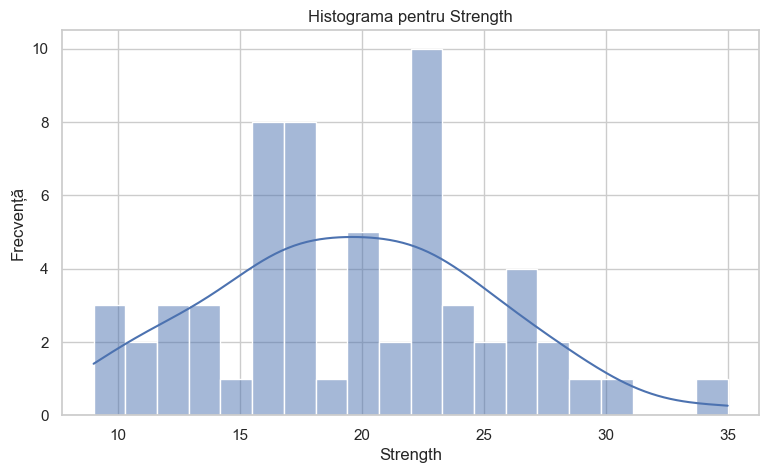

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(series, bins=20, kde=True)
plt.title(f"Histograma pentru {var}")
plt.xlabel(var)
plt.ylabel("Frecvență")
plt.show()


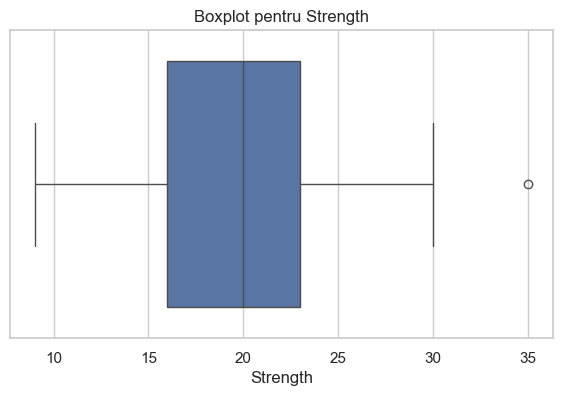

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=series)
plt.title(f"Boxplot pentru {var}")
plt.xlabel(var)
plt.show()


In [ ]:
Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = series[(series < lower_fence) | (series > upper_fence)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Nr outlieri:", len(outliers))
display(outliers.to_frame(var).head(20))


Q1: 16.0
Q3: 23.0
IQR: 7.0
Lower fence: 5.5
Upper fence: 33.5
Nr outlieri: 1


,Strength
29,35


## 9. Analiza pe categorii: groupby și boxplot-uri comparative



In [ ]:
USER_CATEGORY_VAR = None

if USER_CATEGORY_VAR is None:
    category_var = categorical_cols[0] if categorical_cols else None
else:
    category_var = USER_CATEGORY_VAR

print("Variabila categoriala folosita:", category_var)

if category_var is not None:
    group_summary = df.groupby(category_var)[var].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)
    display(group_summary)
else:
    print("Nu exista coloane categoriale detectate pentru analiza pe grupuri.")


Variabila categoriala folosita: AgeGroup


,count,mean,median,std,min,max
AgeGroup,,,,,,
"(21,42]",20,25.4000,25.0,3.604091,19,35
"(42,62]",16,19.5625,20.0,2.475715,16,23
"(62,82]",24,14.7500,15.5,3.602535,9,22


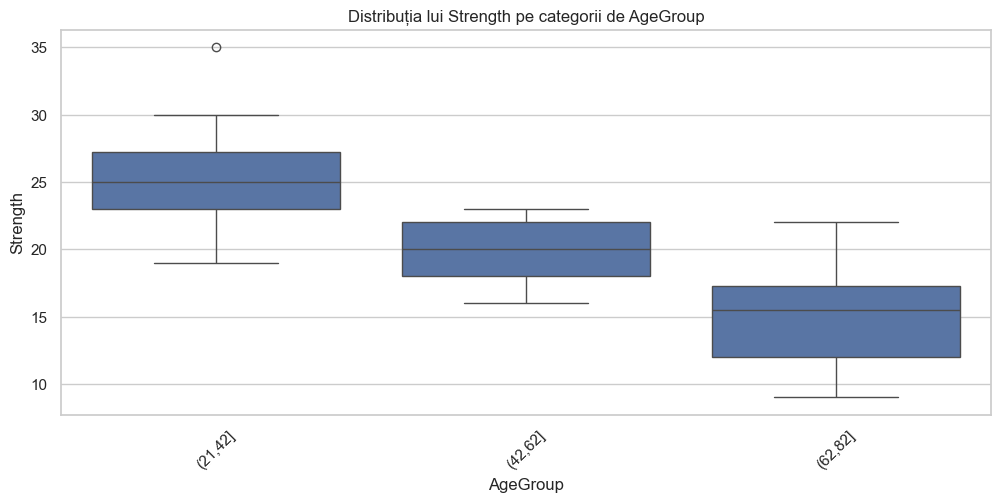

In [ ]:
if category_var is not None:
    top_categories = df[category_var].value_counts().head(10).index
    plot_df = df[df[category_var].isin(top_categories)][[category_var, var]].dropna()

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=plot_df, x=category_var, y=var)
    plt.title(f"Distribuția lui {var} pe categorii de {category_var}")
    plt.xticks(rotation=45)
    plt.show()


## 10. Analiză multivariată non-grafică: covariance și correlation




In [ ]:
USER_X_VAR = "Age"
USER_Y_VAR = "Strength"

if USER_X_VAR is None or USER_Y_VAR is None:
    if len(numeric_cols) < 2:
        raise ValueError("Sunt necesare cel putin doua coloane numerice pentru analiza multivariata.")
    x_var, y_var = numeric_cols[0], numeric_cols[1]
else:
    x_var, y_var = USER_X_VAR, USER_Y_VAR

pair_df = df[[x_var, y_var]].dropna()

covariance = pair_df[x_var].cov(pair_df[y_var])
pearson_corr, pearson_p = stats.pearsonr(pair_df[x_var], pair_df[y_var])
spearman_corr, spearman_p = stats.spearmanr(pair_df[x_var], pair_df[y_var])

print(f"Variabile analizate: {x_var} și {y_var}")
print(f"Covarianta: {covariance:.4f}")
print(f"Corelatie Pearson: {pearson_corr:.4f}, p-value: {pearson_p:.4g}")
print(f"Corelatie Spearman: {spearman_corr:.4f}, p-value: {spearman_p:.4g}")


Variabile analizate: Age și Strength
Covarianta: -85.4068
Corelatie Pearson: -0.8679, p-value: 2.862e-19
Corelatie Spearman: -0.8823, p-value: 1.241e-20


:Interpretare rapidă a corelației Pearson: semnul arată direcția relației, iar valoarea absolută arată intensitatea relației liniare.


In [ ]:
abs_corr = abs(pearson_corr)
if abs_corr < 0.2:
    strength = "foarte slaba"
elif abs_corr < 0.4:
    strength = "slaba"
elif abs_corr < 0.6:
    strength = "moderata"
elif abs_corr < 0.8:
    strength = "puternica"
else:
    strength = "foarte puternica"

direction = "pozitiva" if pearson_corr > 0 else "negativa" if pearson_corr < 0 else "nula"
print(f"Relaria liniara dintre {x_var} si {y_var} este {strength} si {direction}.")


Relaria liniara dintre Age si Strength este foarte puternica si negativa.


## 11. Analiză multivariată grafică: scatter plot



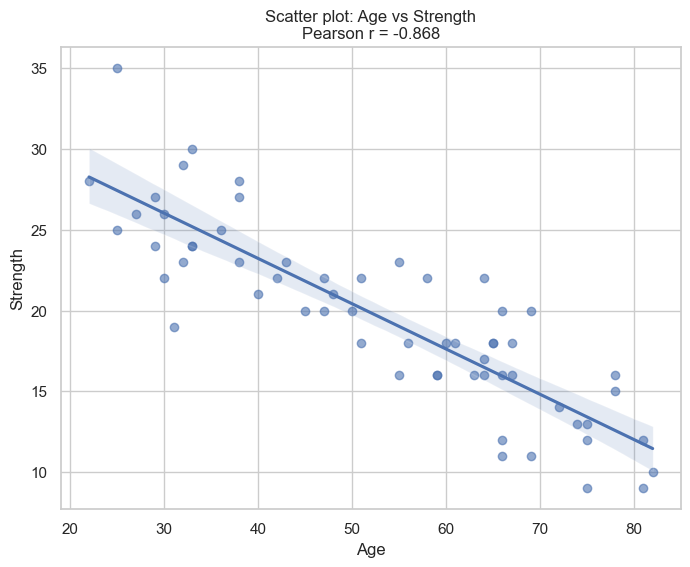

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(data=pair_df, x=x_var, y=y_var, scatter_kws={"alpha": 0.6})
plt.title(f"Scatter plot: {x_var} vs {y_var}\nPearson r = {pearson_corr:.3f}")
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.show()


## 12. Matrice de corelație și heatmap



In [ ]:
corr_matrix = df[numeric_cols].corr(method="pearson")
corr_matrix


,Age,Strength
Age,1.000000,-0.867858
Strength,-0.867858,1.000000


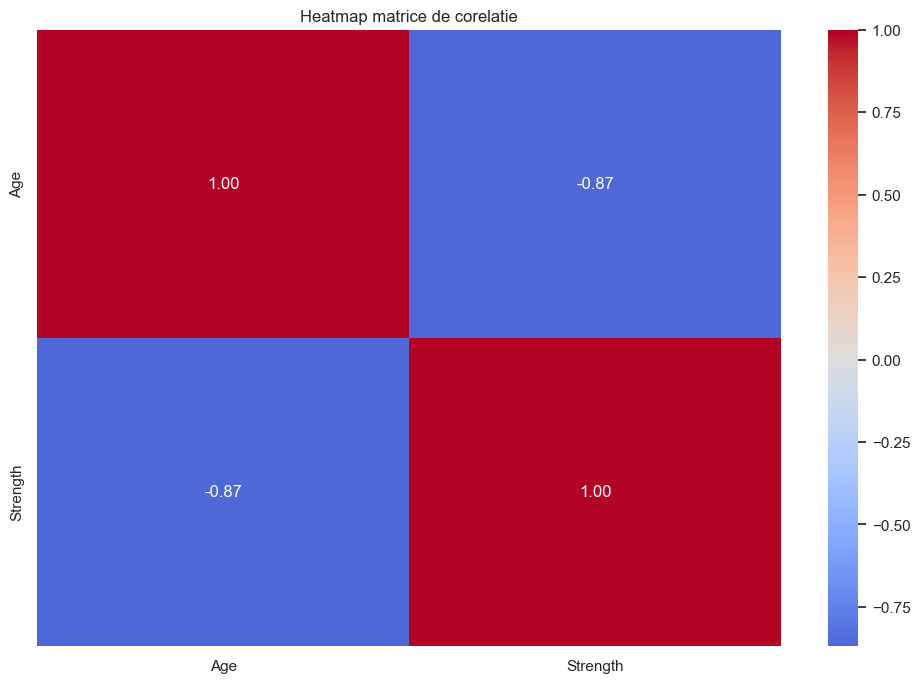

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap matrice de corelatie")
plt.show()


## 13. Extra: pairplot pentru primele variabile numerice

Pairplot-ul este util când vrem să vedem rapid distribuțiile și relațiile dintre mai multe variabile numerice.


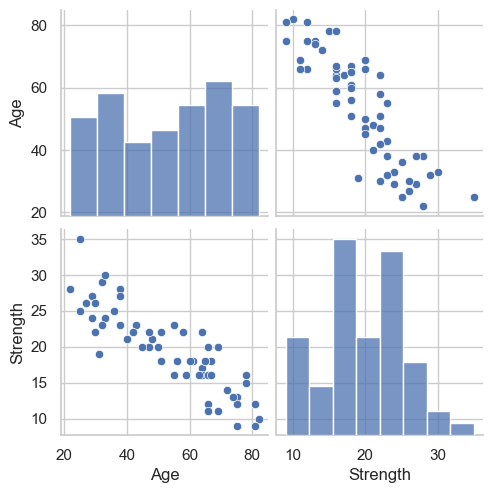

In [ ]:
selected_numeric = numeric_cols[:5]
if len(selected_numeric) >= 2:
    sns.pairplot(df[selected_numeric].dropna())
    plt.show()
else:
    print("Nu există suficiente variabile numerice pentru pairplot.")


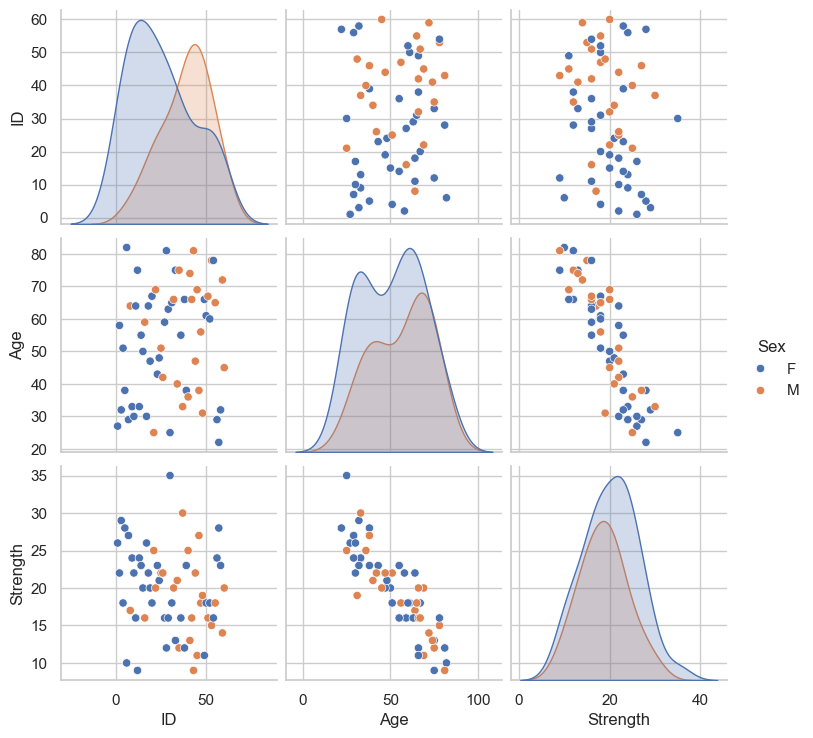

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="Sex")
plt.show()

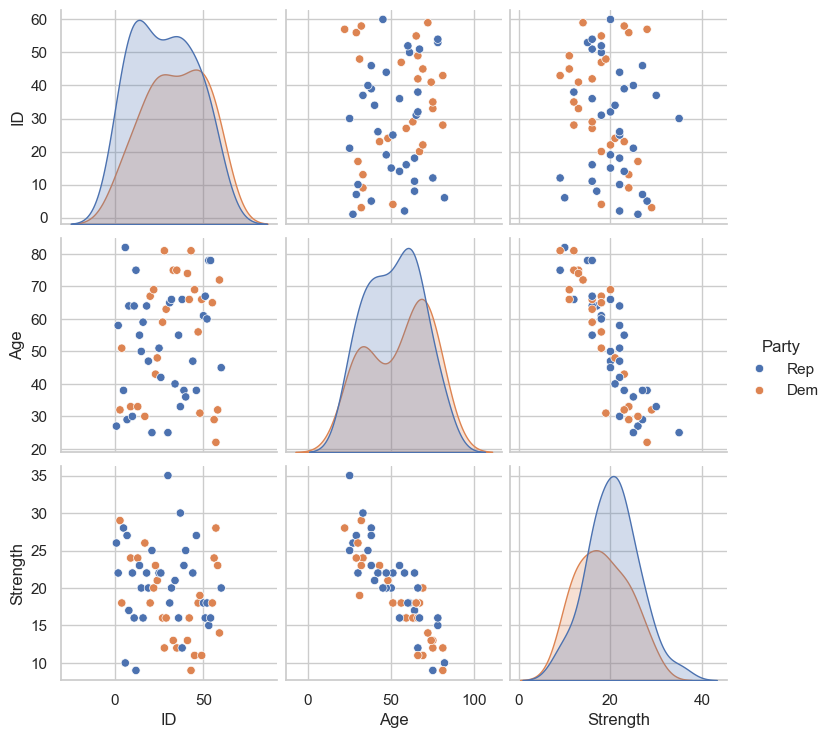

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="Party")
plt.show()

In [ ]:
Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = series[(series < lower_bound) | (series > upper_bound)]

print("Outlieri:")
print(outliers)

Outlieri:
29    35
Name: Strength, dtype: int64


In [ ]:
corr = df["Age"].corr(df["Strength"])

print("Corelatia:", corr)

Corelația: -0.8678583287144026
